In [ ]:
import pandas as pd


file_path = '/home/y/Downloads/data/sierraleone-bumbuna.csv'


try:
    df_sl = pd.read_csv(file_path) 
    print("Sierra Leone Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please check the file path and make sure 'sierraleone-bumbuna.csv' is in the correct location.")


print("\nFirst 5 rows of the Sierra Leone dataset:")
print(df_sl.head())


print("\nSierra Leone Dataset Info:")
df_sl.info()

Sierra Leone Dataset loaded successfully!

First 5 rows of the Sierra Leone dataset:
          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-10-30 00:01 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.1  0.0     0.0   
1  2021-10-30 00:02 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.2  0.0     0.0   
2  2021-10-30 00:03 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.2  0.0     0.0   
3  2021-10-30 00:04 -0.7  0.0 -0.8   0.0   0.0  21.9  99.3  0.0     0.0   
4  2021-10-30 00:05 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.3  0.0     0.0   

   WSstdev   WD  WDstdev    BP  Cleaning  Precipitation  TModA  TModB  \
0      0.0  0.0      0.0  1002         0            0.0   22.3   22.6   
1      0.0  0.0      0.0  1002         0            0.0   22.3   22.6   
2      0.0  0.0      0.0  1002         0            0.0   22.3   22.6   
3      0.0  0.0      0.0  1002         0            0.1   22.3   22.6   
4      0.0  0.0      0.0  1002         0            0.0   22.3   22.6   

   Comments  
0       NaN

In [ ]:

print("Summary Statistics for Sierra Leone Numeric Columns:")
print(df_sl.describe())


print("\nMissing Value Count per Column for Sierra Leone:")
missing_values_sl = df_sl.isna().sum()
print(missing_values_sl)


print("\nSierra Leone Columns with >5% Missing Values:")
total_rows_sl = len(df_sl)
for column, count in missing_values_sl.items():
    percentage = (count / total_rows_sl) * 100
    if percentage > 5:
        print(f"- {column}: {count} missing values ({percentage:.2f}%)")

Summary Statistics for Sierra Leone Numeric Columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.90000

In [ ]:
import numpy as np
from scipy.stats import zscore
import pandas as pd 


outlier_cols_sl = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

print("Calculating Z-scores for outlier detection for Sierra Leone...")


z_scores_sl = df_sl[outlier_cols_sl].apply(zscore, nan_policy='omit') 


outlier_mask_sl = (np.abs(z_scores_sl) > 3).any(axis=1)


df_sl['Potential_Outlier_Zscore'] = outlier_mask_sl

print(f"\nNumber of Sierra Leone rows potentially flagged as outliers based on Z-score (>3): {outlier_mask_sl.sum()}")
print("\nFirst 5 Sierra Leone rows with outlier flag:")

cols_to_display_sl = ['Timestamp'] + outlier_cols_sl + ['Potential_Outlier_Zscore']
print(df_sl[cols_to_display_sl].head())



print("\nHandling missing values for Sierra Leone...")
if 'Comments' in df_sl.columns:
    df_sl = df_sl.drop('Comments', axis=1)
    print("Dropped the 'Comments' column from Sierra Leone data due to 100% missing values.")
else:
    print("'Comments' column not found or already dropped in Sierra Leone data.")


print("\nCleaning steps completed for Sierra Leone.")
print("\nSierra Leone Dataset Info after dropping 'Comments' column:")
df_sl.info() 

Calculating Z-scores for outlier detection for Sierra Leone...

Number of Sierra Leone rows potentially flagged as outliers based on Z-score (>3): 16292

First 5 Sierra Leone rows with outlier flag:
          Timestamp  GHI  DNI  DHI  ModA  ModB   WS  WSgust  \
0  2021-10-30 00:01 -0.7 -0.1 -0.8   0.0   0.0  0.0     0.0   
1  2021-10-30 00:02 -0.7 -0.1 -0.8   0.0   0.0  0.0     0.0   
2  2021-10-30 00:03 -0.7 -0.1 -0.8   0.0   0.0  0.0     0.0   
3  2021-10-30 00:04 -0.7  0.0 -0.8   0.0   0.0  0.0     0.0   
4  2021-10-30 00:05 -0.7 -0.1 -0.8   0.0   0.0  0.0     0.0   

   Potential_Outlier_Zscore  
0                     False  
1                     False  
2                     False  
3                     False  
4                     False  

Handling missing values for Sierra Leone...
Dropped the 'Comments' column from Sierra Leone data due to 100% missing values.

Cleaning steps completed for Sierra Leone.

Sierra Leone Dataset Info after dropping 'Comments' column:
<class 'pan

In [ ]:
import os
import pandas as pd 

output_dir_sl = '../data/'
output_file_path_sl = os.path.join(output_dir_sl, 'sierraleone_clean.csv')


print(f"Ensuring directory '{output_dir_sl}' exists for Sierra Leone...")
os.makedirs(output_dir_sl, exist_ok=True)
print(f"Directory '{output_dir_sl}' checked/created for Sierra Leone.")


print(f"\nExporting cleaned Sierra Leone data to '{output_file_path_sl}'...")
df_sl.to_csv(output_file_path_sl, index=False)
print("Cleaned Sierra Leone data exported successfully!")

Ensuring directory '../data/' exists for Sierra Leone...
Directory '../data/' checked/created for Sierra Leone.

Exporting cleaned Sierra Leone data to '../data/sierraleone_clean.csv'...
Cleaned Sierra Leone data exported successfully!


Converting 'Timestamp' column to datetime for Sierra Leone...
'Timestamp' column converted to datetime for Sierra Leone.

Generating Time Series Plots for GHI, DNI, DHI, and Tamb for Sierra Leone...


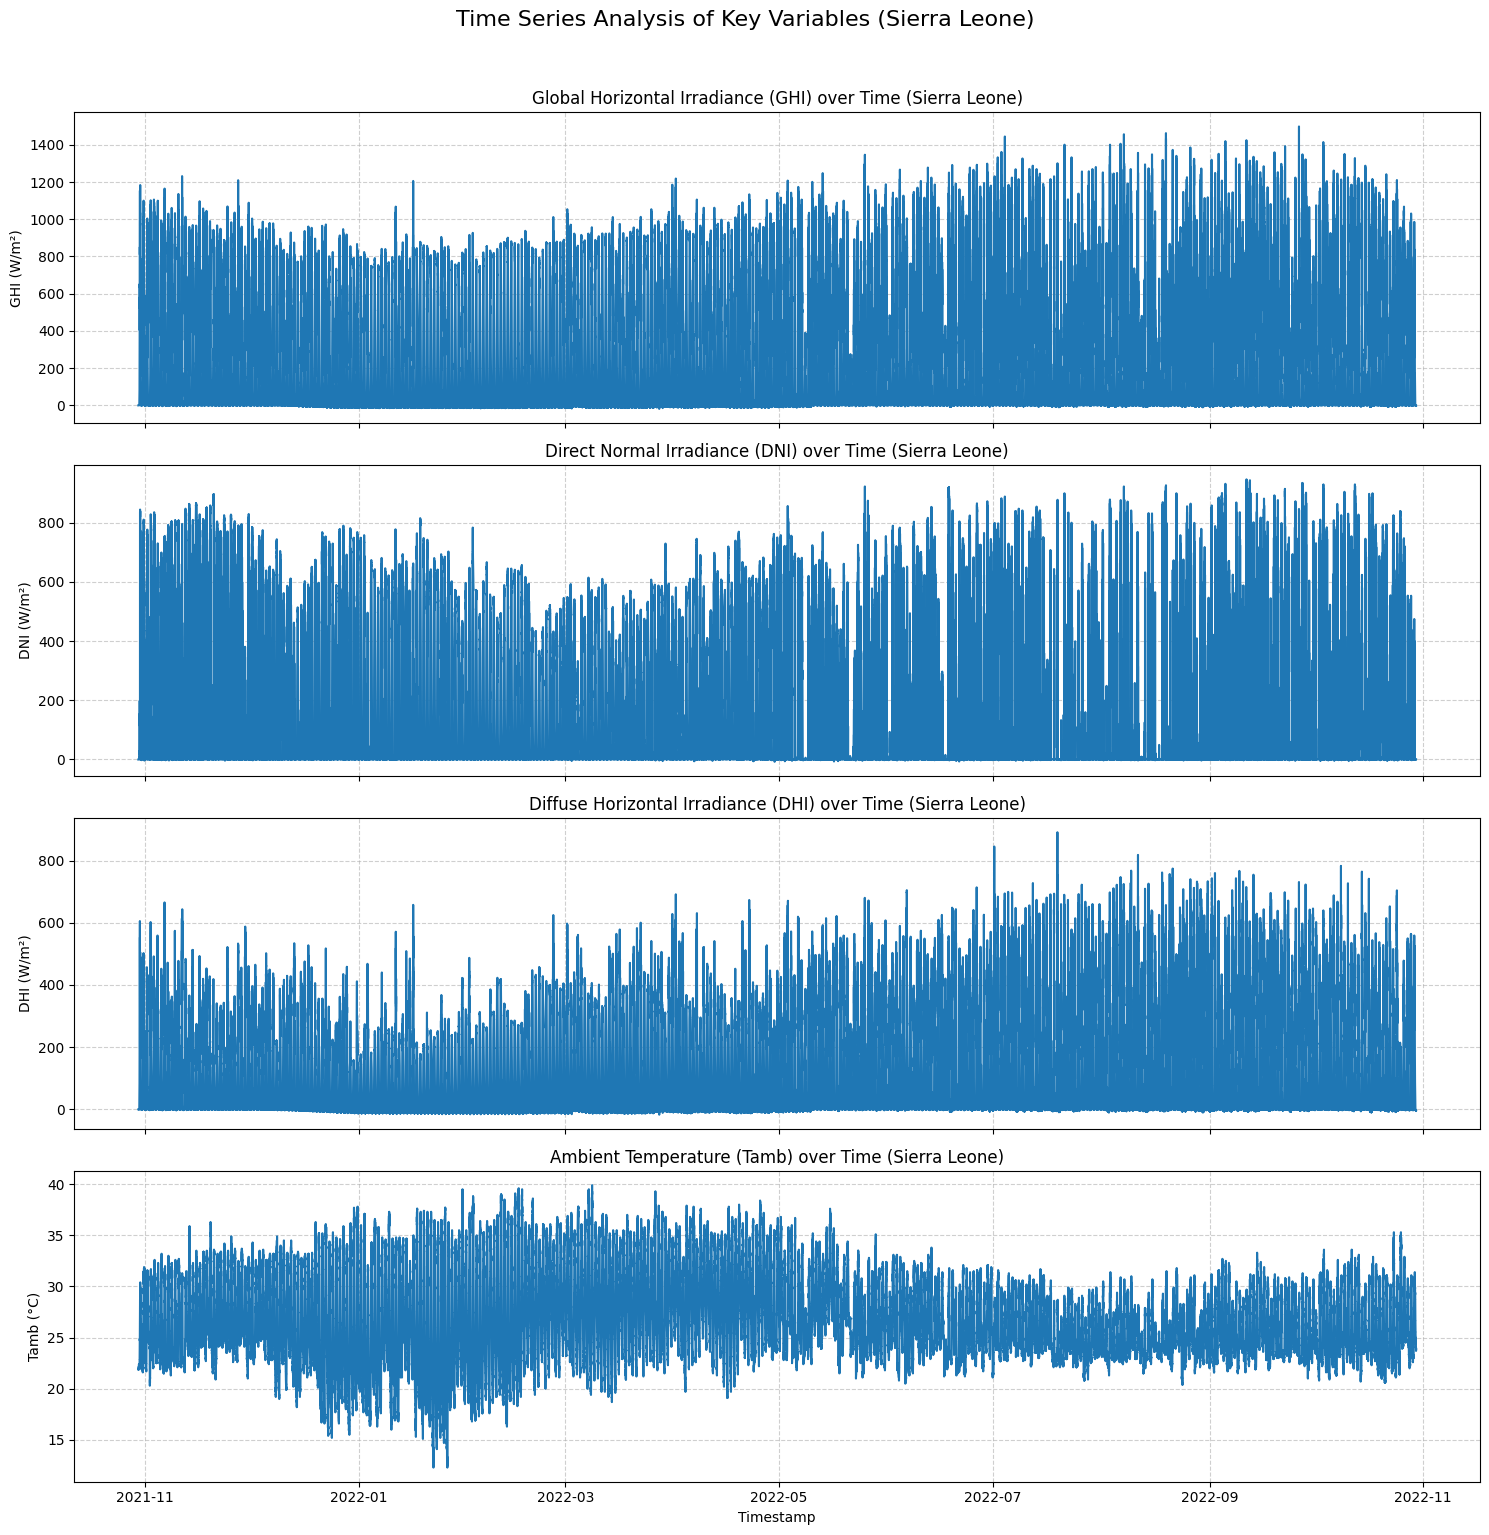


Time Series Plots generated for Sierra Leone.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# --- Prepare Timestamp Column ---

print("Converting 'Timestamp' column to datetime for Sierra Leone...")

df_sl['Timestamp'] = pd.to_datetime(df_sl['Timestamp'], errors='coerce')
print("'Timestamp' column converted to datetime for Sierra Leone.")


# --- Time Series Analysis Plots ---

print("\nGenerating Time Series Plots for GHI, DNI, DHI, and Tamb for Sierra Leone...")

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 15), sharex=True)
fig.suptitle('Time Series Analysis of Key Variables (Sierra Leone)', y=1.02, fontsize=16)

# Plot GHI vs Timestamp
sns.lineplot(ax=axes[0], x=df_sl['Timestamp'], y=df_sl['GHI'])
axes[0].set_title('Global Horizontal Irradiance (GHI) over Time (Sierra Leone)')
axes[0].set_ylabel('GHI (W/m²)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot DNI vs Timestamp
sns.lineplot(ax=axes[1], x=df_sl['Timestamp'], y=df_sl['DNI'])
axes[1].set_title('Direct Normal Irradiance (DNI) over Time (Sierra Leone)')
axes[1].set_ylabel('DNI (W/m²)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot DHI vs Timestamp
sns.lineplot(ax=axes[2], x=df_sl['Timestamp'], y=df_sl['DHI'])
axes[2].set_title('Diffuse Horizontal Irradiance (DHI) over Time (Sierra Leone)')
axes[2].set_ylabel('DHI (W/m²)')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Plot Tamb vs Timestamp
sns.lineplot(ax=axes[3], x=df_sl['Timestamp'], y=df_sl['Tamb'])
axes[3].set_title('Ambient Temperature (Tamb) over Time (Sierra Leone)')
axes[3].set_ylabel('Tamb (°C)')
axes[3].set_xlabel('Timestamp') # Only the bottom plot needs the x-label
axes[3].grid(True, linestyle='--', alpha=0.6)


# Improve layout and display the plots
plt.tight_layout()
plt.show()

print("\nTime Series Plots generated for Sierra Leone.")

Analyzing Cleaning Impact on average ModA and ModB for Sierra Leone...

Average ModA and ModB grouped by Cleaning flag (0: No Cleaning, 1: Cleaning) for Sierra Leone:
                ModA        ModB
Cleaning                        
0         206.578599  198.038150
1         273.309252  277.231102


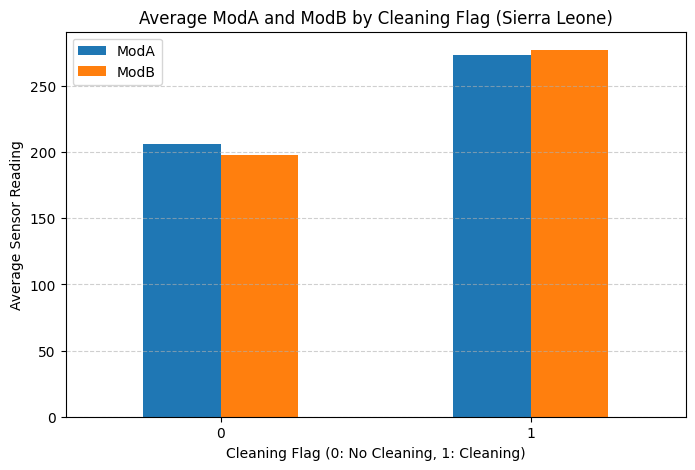


Cleaning Impact analysis completed for Sierra Leone.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 



print("Analyzing Cleaning Impact on average ModA and ModB for Sierra Leone...")


cleaning_impact_sl = df_sl.groupby('Cleaning')[['ModA', 'ModB']].mean()

print("\nAverage ModA and ModB grouped by Cleaning flag (0: No Cleaning, 1: Cleaning) for Sierra Leone:")
print(cleaning_impact_sl)

# Plot the cleaning impact
cleaning_impact_sl.plot(kind='bar', figsize=(8, 5))
plt.title('Average ModA and ModB by Cleaning Flag (Sierra Leone)')
plt.xlabel('Cleaning Flag (0: No Cleaning, 1: Cleaning)')
plt.ylabel('Average Sensor Reading')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\nCleaning Impact analysis completed for Sierra Leone.")

Generating Correlation Heatmap for Sierra Leone...


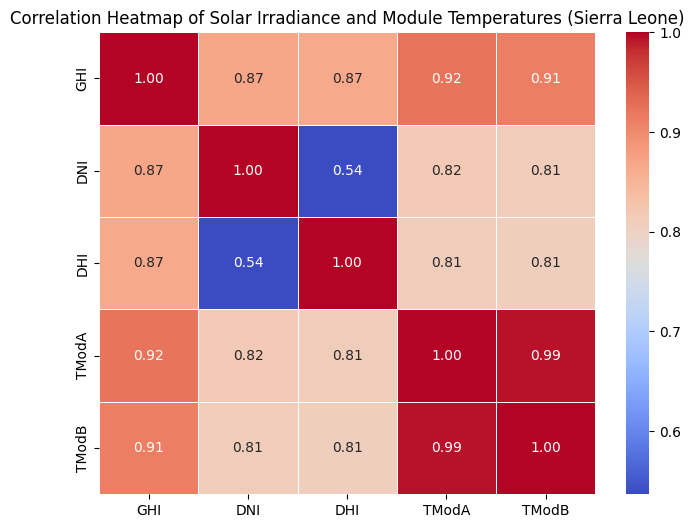


Correlation Heatmap generated for Sierra Leone.

Generating Scatter Plots for Sierra Leone...


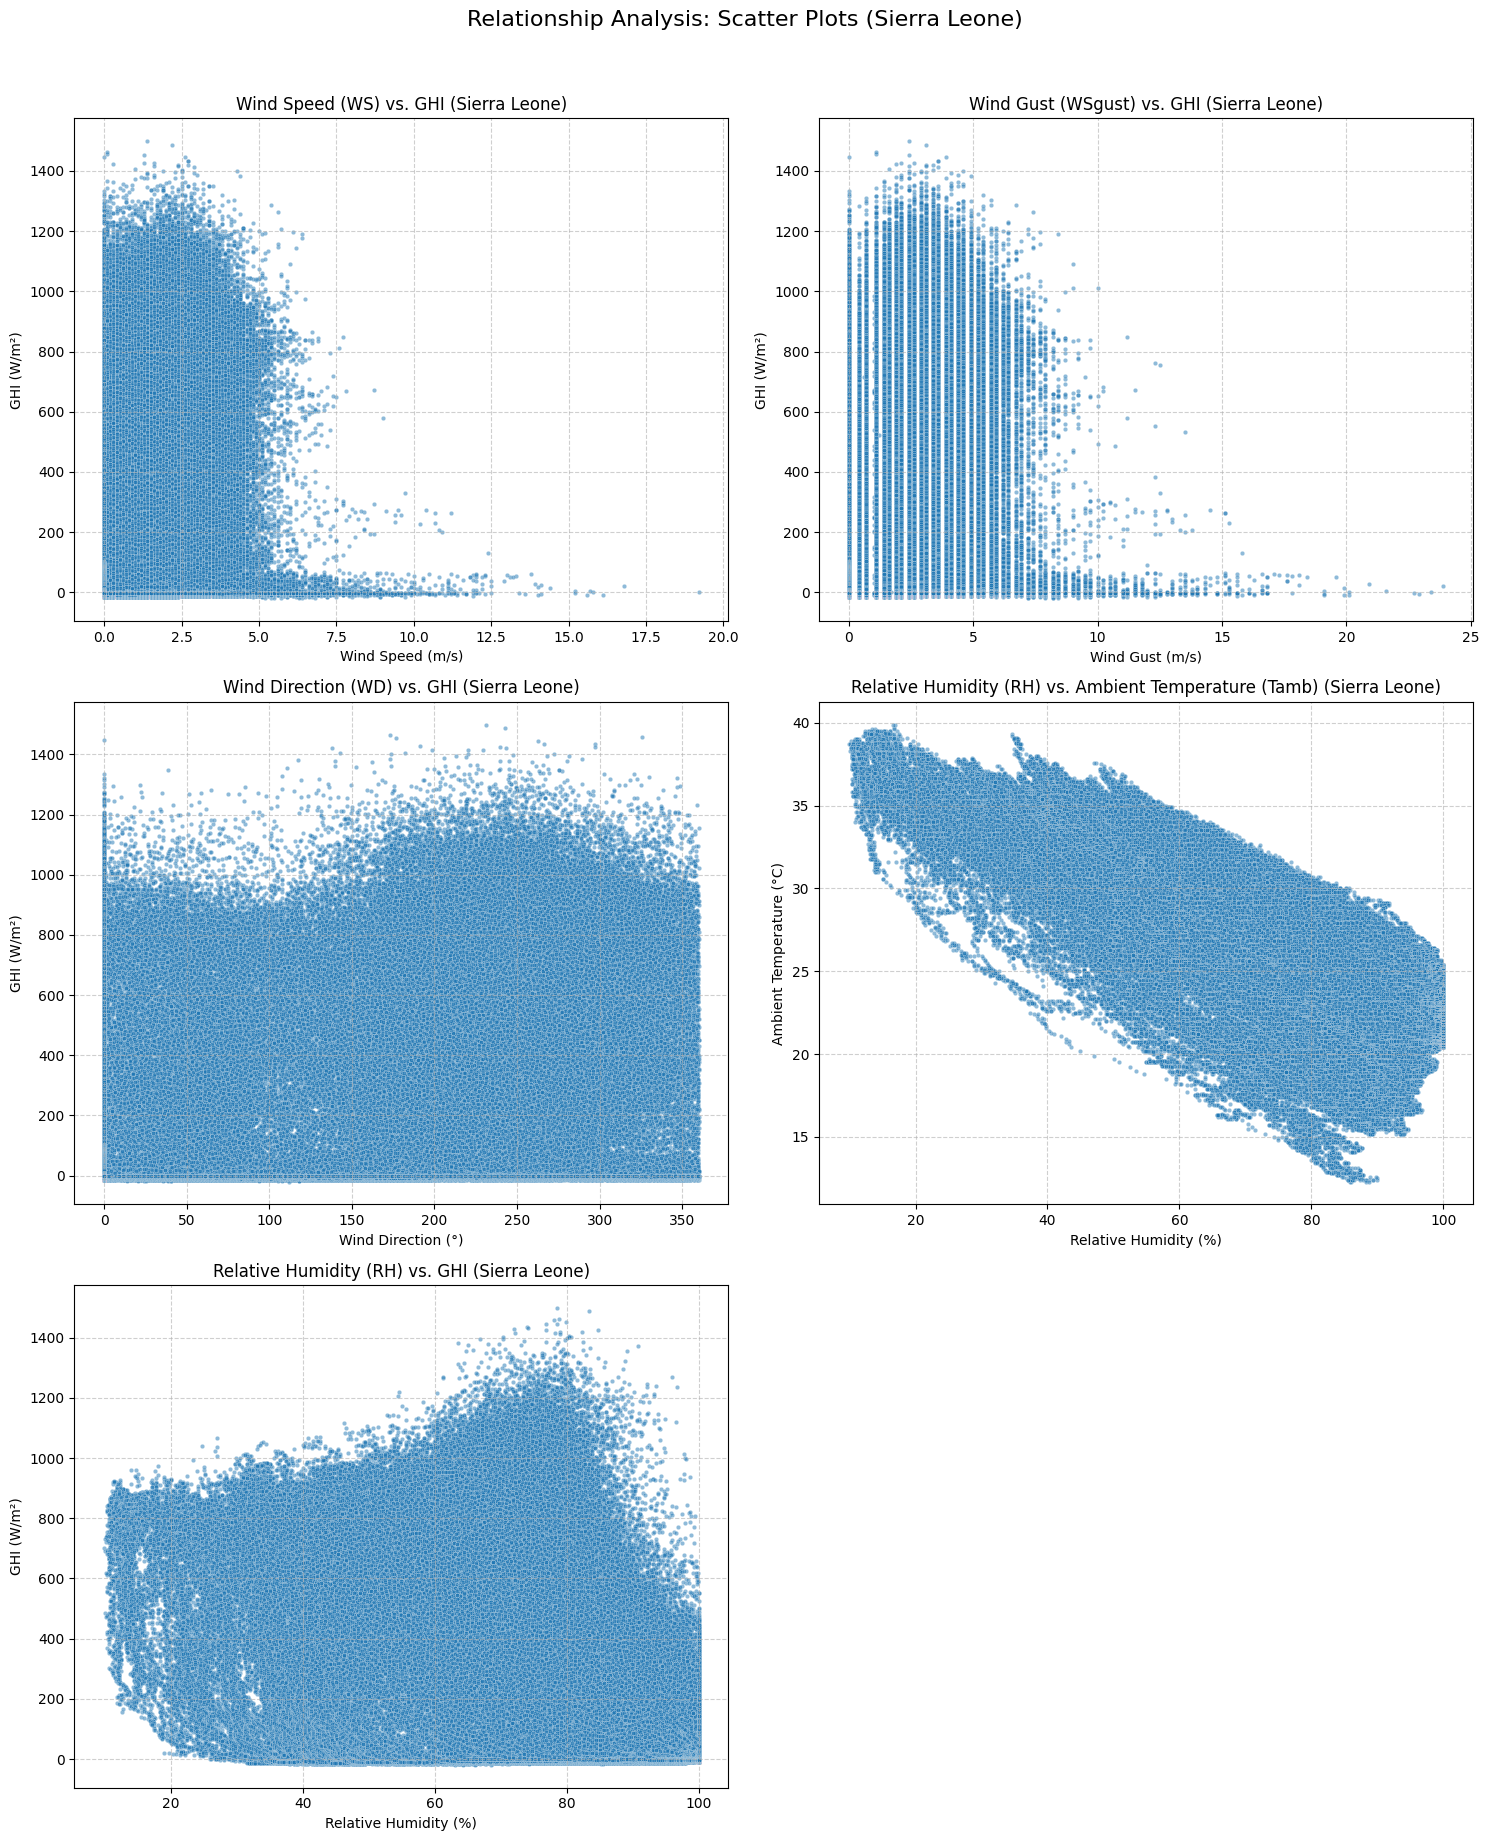


Scatter Plots generated for Sierra Leone.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 



print("Generating Correlation Heatmap for Sierra Leone...")


heatmap_cols_sl = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']


correlation_matrix_sl = df_sl[heatmap_cols_sl].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_sl, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Solar Irradiance and Module Temperatures (Sierra Leone)')
plt.show()

print("\nCorrelation Heatmap generated for Sierra Leone.")



print("\nGenerating Scatter Plots for Sierra Leone...")


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
fig.suptitle('Relationship Analysis: Scatter Plots (Sierra Leone)', y=1.02, fontsize=16)

# Scatter plot: WS vs GHI
sns.scatterplot(ax=axes[0, 0], data=df_sl, x='WS', y='GHI', alpha=0.5, s=10) # s is marker size
axes[0, 0].set_title('Wind Speed (WS) vs. GHI (Sierra Leone)')
axes[0, 0].set_xlabel('Wind Speed (m/s)')
axes[0, 0].set_ylabel('GHI (W/m²)')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: WSgust vs GHI
sns.scatterplot(ax=axes[0, 1], data=df_sl, x='WSgust', y='GHI', alpha=0.5, s=10)
axes[0, 1].set_title('Wind Gust (WSgust) vs. GHI (Sierra Leone)')
axes[0, 1].set_xlabel('Wind Gust (m/s)')
axes[0, 1].set_ylabel('GHI (W/m²)')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: WD vs GHI
sns.scatterplot(ax=axes[1, 0], data=df_sl, x='WD', y='GHI', alpha=0.5, s=10)
axes[1, 0].set_title('Wind Direction (WD) vs. GHI (Sierra Leone)')
axes[1, 0].set_xlabel('Wind Direction (°)')
axes[1, 0].set_ylabel('GHI (W/m²)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: RH vs Tamb
sns.scatterplot(ax=axes[1, 1], data=df_sl, x='RH', y='Tamb', alpha=0.5, s=10)
axes[1, 1].set_title('Relative Humidity (RH) vs. Ambient Temperature (Tamb) (Sierra Leone)')
axes[1, 1].set_xlabel('Relative Humidity (%)')
axes[1, 1].set_ylabel('Ambient Temperature (°C)')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Scatter plot: RH vs GHI
sns.scatterplot(ax=axes[2, 0], data=df_sl, x='RH', y='GHI', alpha=0.5, s=10)
axes[2, 0].set_title('Relative Humidity (RH) vs. GHI (Sierra Leone)')
axes[2, 0].set_xlabel('Relative Humidity (%)')
axes[2, 0].set_ylabel('GHI (W/m²)')
axes[2, 0].grid(True, linestyle='--', alpha=0.6)

# Hide the unused subplot
fig.delaxes(axes[2, 1])

# Improve layout and display the plots
plt.tight_layout()
plt.show()

print("\nScatter Plots generated for Sierra Leone.")

Generating Histograms for GHI and WS for Sierra Leone...


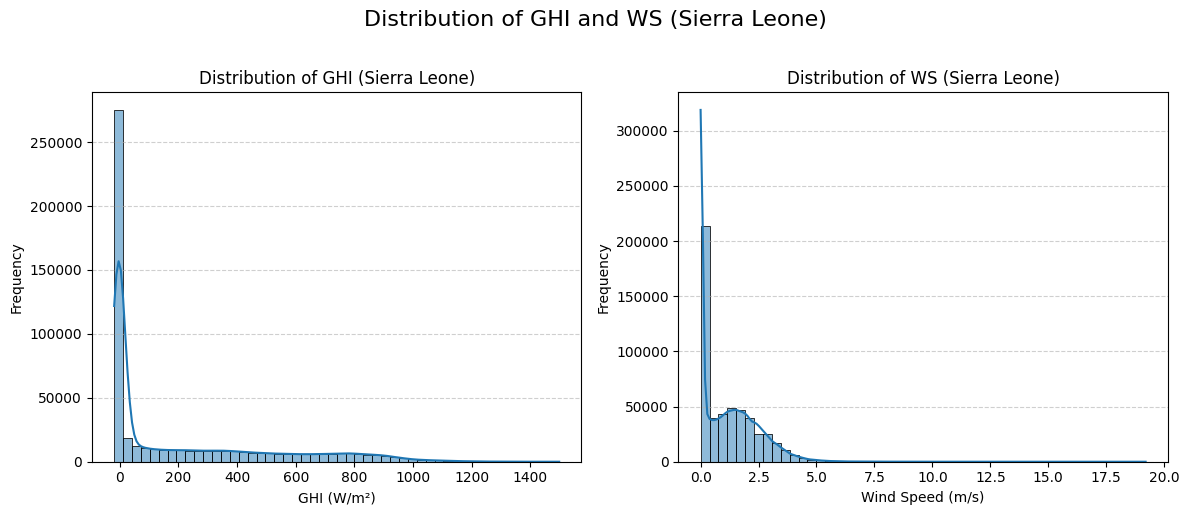


Histograms generated for Sierra Leone.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np 



print("Generating Histograms for GHI and WS for Sierra Leone...")


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle('Distribution of GHI and WS (Sierra Leone)', y=1.02, fontsize=16)

# Histogram for GHI
sns.histplot(ax=axes[0], data=df_sl, x='GHI', kde=True, bins=50) # kde=True adds a density curve
axes[0].set_title('Distribution of GHI (Sierra Leone)')
axes[0].set_xlabel('GHI (W/m²)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Histogram for WS
sns.histplot(ax=axes[1], data=df_sl, x='WS', kde=True, bins=50)
axes[1].set_title('Distribution of WS (Sierra Leone)')
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

print("\nHistograms generated for Sierra Leone.")


Generating Wind Rose Plot for Sierra Leone...


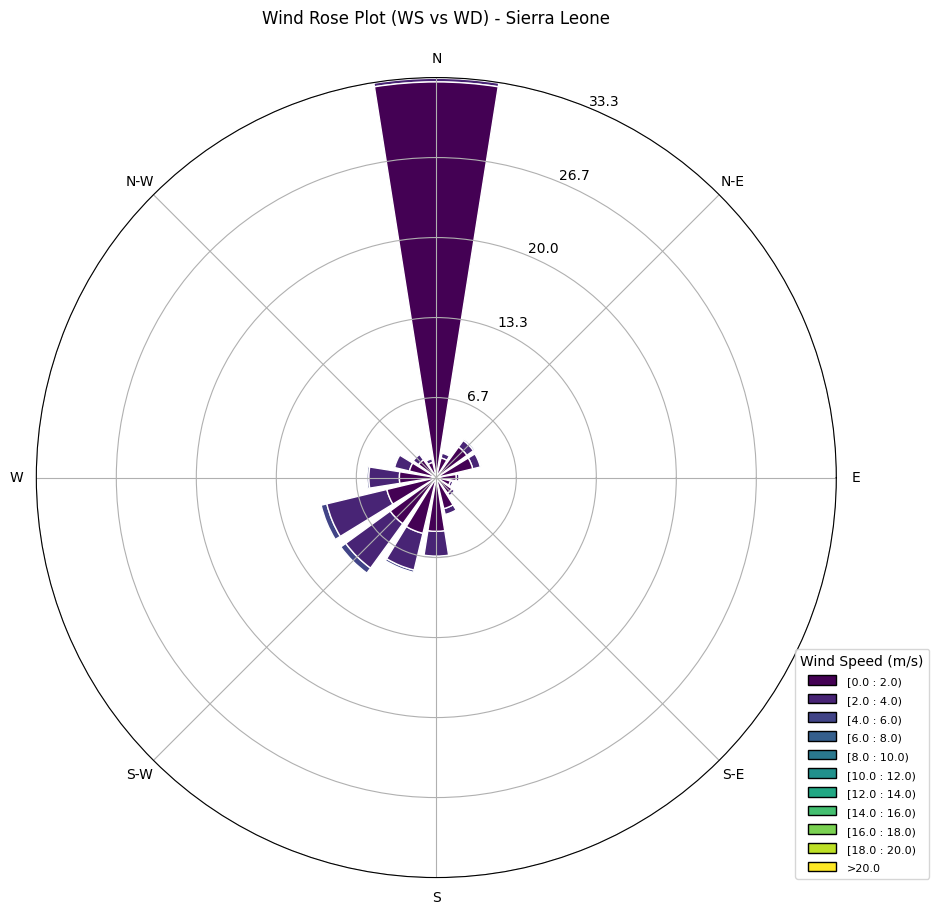

Wind Rose Plot generated for Sierra Leone.


In [ ]:
# --- Wind Analysis (Wind Rose) ---

import matplotlib.pyplot as plt 
import matplotlib.cm as cm 
import numpy as np 
import pandas as pd 

print("\nGenerating Wind Rose Plot for Sierra Leone...")

try:
    from windrose import WindroseAxes

    # Create a new figure
    fig = plt.figure(figsize=(10, 10))
    # Create a WindroseAxes instance
    ax = WindroseAxes.from_ax(fig=fig, rect=[0.1, 0.1, 0.8, 0.8])

    
    ax.bar(df_sl['WD'], df_sl['WS'], normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, df_sl['WS'].max() + 1, 2), cmap=cm.viridis)

    # Set title
    ax.set_title('Wind Rose Plot (WS vs WD) - Sierra Leone', pad=20)

    # Add legend
    ax.set_legend(title="Wind Speed (m/s)", loc="lower left", bbox_to_anchor=(0.95, 0)) # Position legend outside plot

    plt.show()
    print("Wind Rose Plot generated for Sierra Leone.")

except ImportError:
    print("The 'windrose' library is not installed in your current environment.")
    print("Please install it using: pip install windrose in your active terminal or VS Code integrated terminal.")
    print("Skipping Wind Rose plot generation for Sierra Leone.")
except NameError:
    print("Error: DataFrame 'df_sl' not found. Please run the data loading cell (Step 4 for Sierra Leone) first.")
except Exception as e:
    print(f"An error occurred while generating the Wind Rose plot for Sierra Leone: {e}")


Generating Bubble Chart (GHI vs Tamb, Bubble Size = RH) for Sierra Leone...


/home/y/MoonLight-Energy-Solutions-solar/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


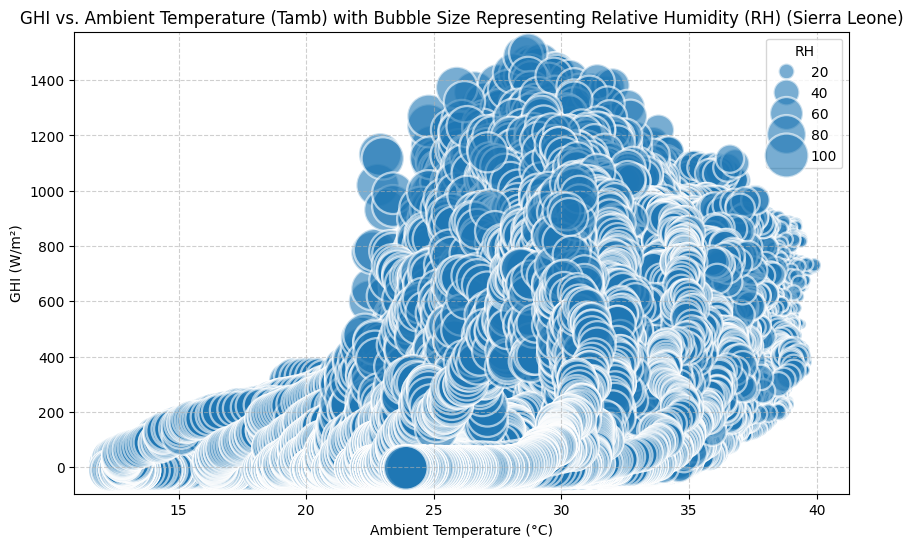


Bubble Chart generated for Sierra Leone.


In [ ]:
# --- Bubble Chart Analysis ---

import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

print("\nGenerating Bubble Chart (GHI vs Tamb, Bubble Size = RH) for Sierra Leone...")

try:
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_sl, x='Tamb', y='GHI', size='RH', alpha=0.6, sizes=(20, 1000)) # sizes controls the range of bubble sizes

    plt.title('GHI vs. Ambient Temperature (Tamb) with Bubble Size Representing Relative Humidity (RH) (Sierra Leone)')
    plt.xlabel('Ambient Temperature (°C)')
    plt.ylabel('GHI (W/m²)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    print("\nBubble Chart generated for Sierra Leone.")

   

except NameError:
     print("Error: DataFrame 'df_sl' not found. Please run the data loading cell (Step 4 for Sierra Leone) first.")
except Exception as e:
    print(f"An error occurred while generating the Bubble Chart for Sierra Leone: {e}")